## Objective: Develop a model to predict heart disease with accuracy.

### Import Necessery Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

### Import Dataset

In [7]:
datapath='heart.csv'
df=pd.read_csv(datapath)

### EDA

In [9]:
df.sample(5)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
251268,No,36.92,No,No,No,0.0,0.0,Yes,Female,60-64,White,Yes,No,Good,6.0,No,No,No
218981,No,46.58,Yes,Yes,No,6.0,0.0,No,Male,30-34,American Indian/Alaskan Native,No,No,Good,6.0,No,No,No
189071,No,34.97,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Very good,6.0,No,No,No
103074,No,24.83,Yes,No,No,0.0,0.0,No,Male,30-34,White,No,Yes,Very good,8.0,No,No,No
28848,No,27.12,No,No,No,0.0,15.0,No,Male,35-39,White,No,Yes,Good,8.0,No,No,No


In [10]:
df.shape

(319795, 18)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [12]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,319795.0,28.325399,6.356100,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,319795.0,3.371710,7.950850,0.00,0.00,0.00,2.00,30.00
MentalHealth,319795.0,3.898366,7.955235,0.00,0.00,0.00,3.00,30.00
SleepTime,319795.0,7.097075,1.436007,1.00,6.00,7.00,8.00,24.00


In [14]:
cols=df.columns.tolist()
print(cols)

['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


### Preprocessing

In [16]:
sum=0;
for i in cols:
    if(df[i].nunique()<20):
        sum+=1
        print(df[i].value_counts())
        print('----------------------------')
print(f"Total:",sum)

HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64
----------------------------
Smoking
No     187887
Yes    131908
Name: count, dtype: int64
----------------------------
AlcoholDrinking
No     298018
Yes     21777
Name: count, dtype: int64
----------------------------
Stroke
No     307726
Yes     12069
Name: count, dtype: int64
----------------------------
DiffWalking
No     275385
Yes     44410
Name: count, dtype: int64
----------------------------
Sex
Female    167805
Male      151990
Name: count, dtype: int64
----------------------------
AgeCategory
65-69          34151
60-64          33686
70-74          31065
55-59          29757
50-54          25382
80 or older    24153
45-49          21791
75-79          21482
18-24          21064
40-44          21006
35-39          20550
30-34          18753
25-29          16955
Name: count, dtype: int64
----------------------------
Race
White                             245212
Hispanic                           27446
Black    

In [17]:
df['HeartDisease']=df['HeartDisease'].map({'No':0,'Yes':1})

In [18]:
df['Smoking']=df['Smoking'].map({'No':0,'Yes':1})

In [19]:
df['AlcoholDrinking']=df['AlcoholDrinking'].map({'No':0,'Yes':1})

In [20]:
df['Stroke']=df['Stroke'].map({'No':0,'Yes':1})

In [21]:
df['DiffWalking']=df['DiffWalking'].map({'No':0,'Yes':1})

In [22]:
df['Sex']=df['Sex'].map({'Female':0,'Male':1})

In [23]:
df['PhysicalActivity']=df['PhysicalActivity'].map({'No':0,'Yes':1})

In [24]:
df['Asthma']=df['Asthma'].map({'No':0,'Yes':1})

In [25]:
df['KidneyDisease']=df['KidneyDisease'].map({'No':0,'Yes':1})

In [26]:
df['SkinCancer']=df['SkinCancer'].map({'No':0,'Yes':1})

In [27]:
df['GenHealth']=df['GenHealth'].map({'Very good':0,'Good':1,'Excellent':2,'Fair':3,'Poor':4})

In [28]:
df['Diabetic']=df['Diabetic'].map({'No':0,'Yes':1,'No, borderline diabetes':3,'Yes (during pregnancy)':4})

In [29]:
age_mapping = {
    '18-24': 1, '25-29': 2, '30-34': 3, '35-39': 4, '40-44': 5,
    '45-49': 6, '50-54': 7, '55-59': 8, '60-64': 9, '65-69': 10,
    '70-74': 11, '75-79': 12, '80 or older': 13
}

df['AgeCategory'] = df['AgeCategory'].map(age_mapping)

In [30]:
df.sample(5)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
258429,0,20.60,0,0,0,30.0,0.0,1,0,10,White,0,1,4,8.0,0,0,0
194512,0,23.62,0,0,0,0.0,1.0,0,0,1,Black,0,1,2,7.0,0,0,0
82129,0,35.44,0,0,0,0.0,0.0,0,1,10,White,3,1,1,8.0,0,0,0
61020,0,23.49,0,0,0,0.0,0.0,0,0,9,White,1,0,1,8.0,0,0,0
67955,0,31.46,1,0,0,15.0,0.0,1,0,9,Asian,1,1,4,8.0,1,1,0


In [31]:
df=df.drop_duplicates()

### Visualization

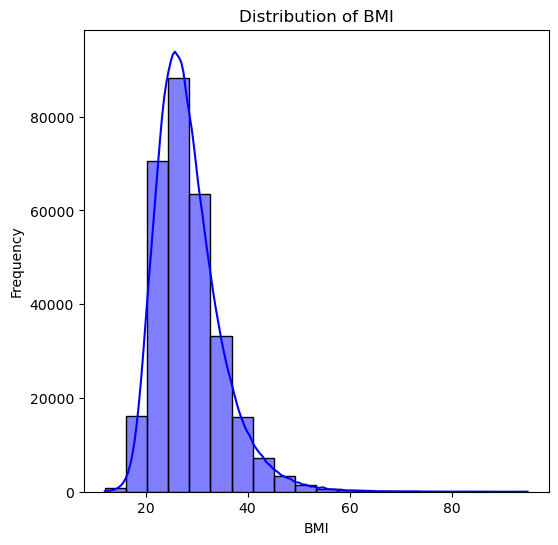

In [33]:
plt.figure(figsize=(6, 6))
sns.histplot(df['BMI'], kde=True, bins=20, color='blue')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

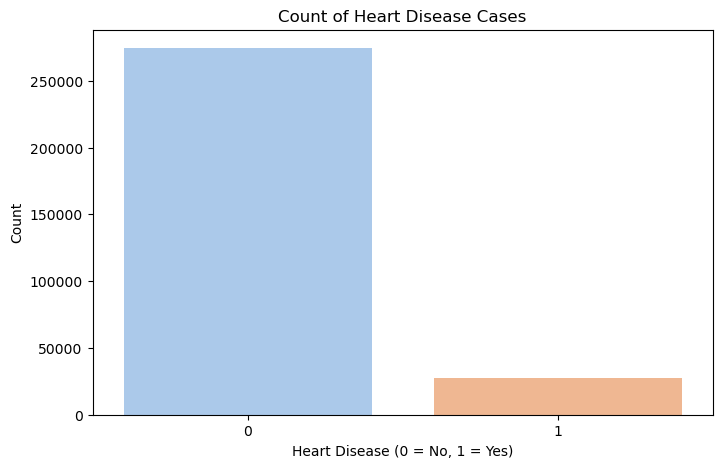

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="HeartDisease", hue="HeartDisease", palette="pastel", legend=False)
plt.title("Count of Heart Disease Cases")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

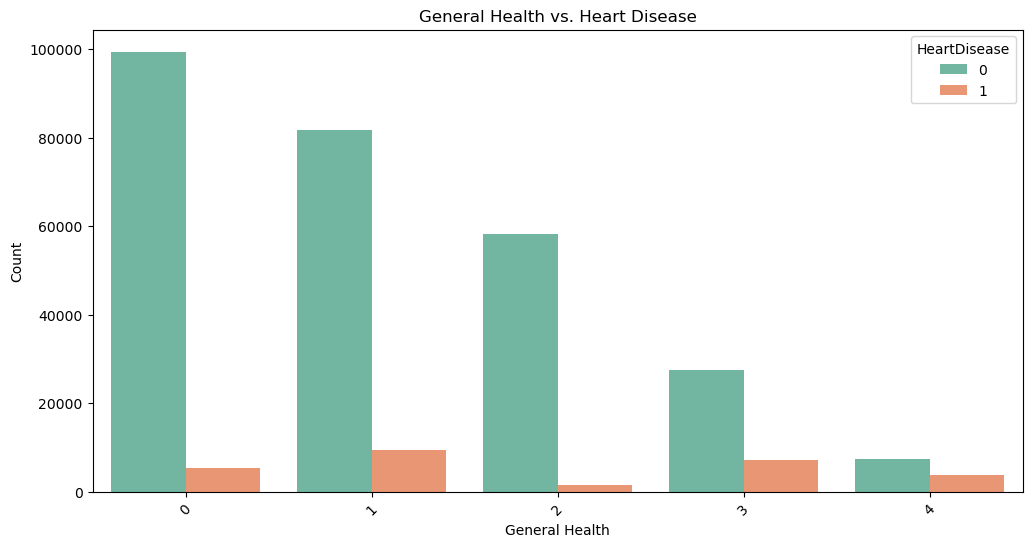

In [35]:
# Barplot for General Health by Heart Disease
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="GenHealth", hue="HeartDisease", palette="Set2")
plt.title("General Health vs. Heart Disease")
plt.xlabel("General Health")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

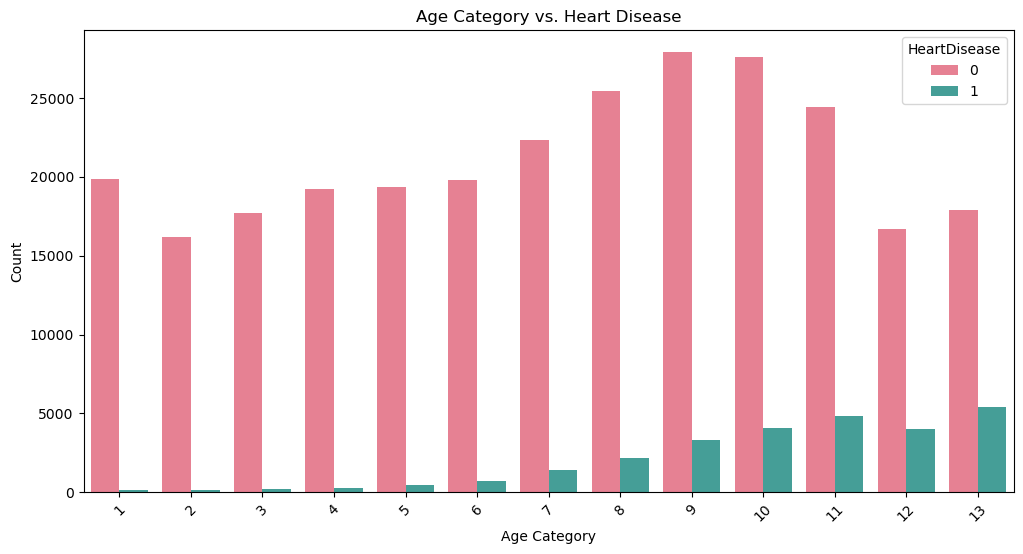

In [36]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="AgeCategory", hue="HeartDisease", palette="husl")
plt.title("Age Category vs. Heart Disease")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

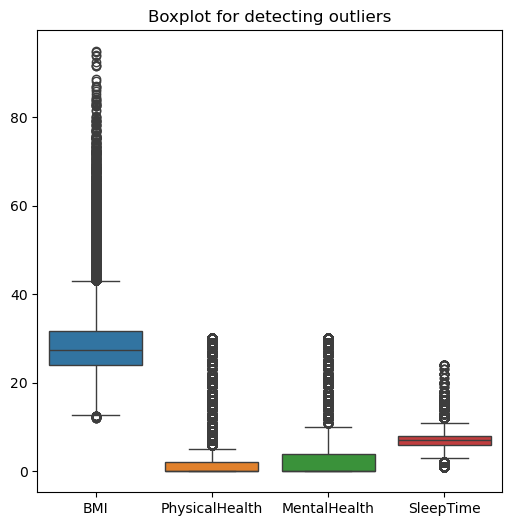

In [37]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df[["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]])
plt.title("Boxplot for detecting outliers")
plt.show()

In [38]:
columns_to_check = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

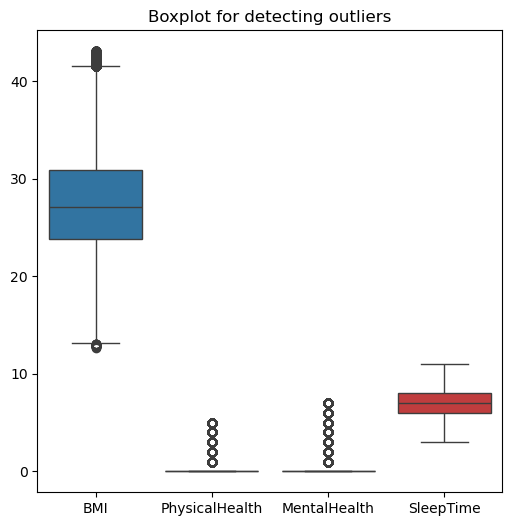

In [39]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df[["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]])
plt.title("Boxplot for detecting outliers")
plt.show()

In [40]:
df_sample=df.drop(['AgeCategory','Race'],axis=1)
correlation_matrix = df_sample.corr()

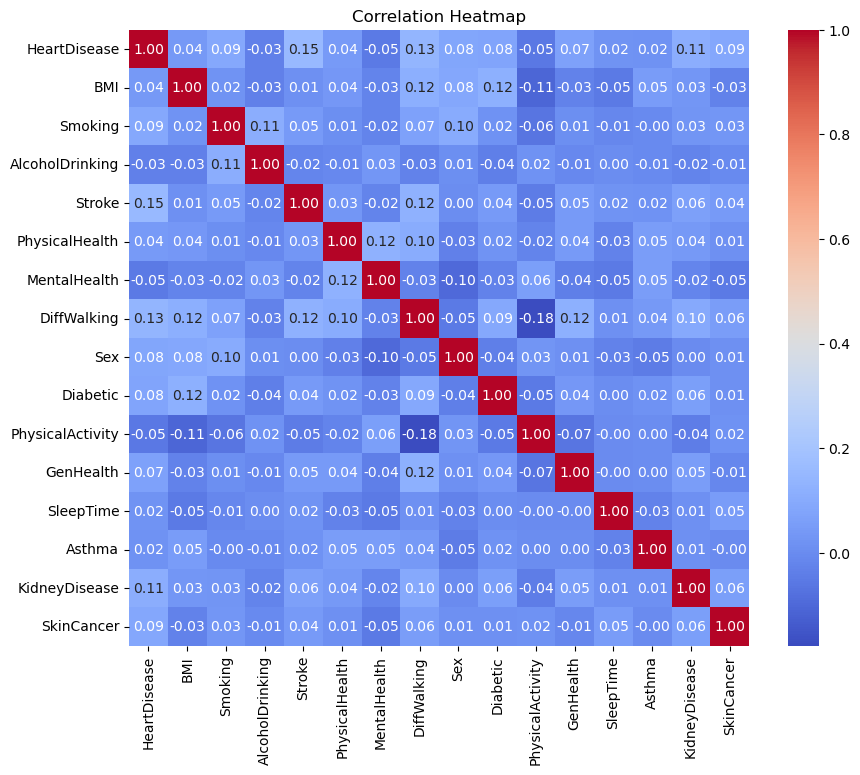

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# Display the plot
plt.title("Correlation Heatmap")
plt.show()

In [42]:
df.shape

(213956, 18)

### Model Selection

In [44]:
y=df['HeartDisease']
x=df.drop(['Race','HeartDisease'],axis=1)

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [46]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

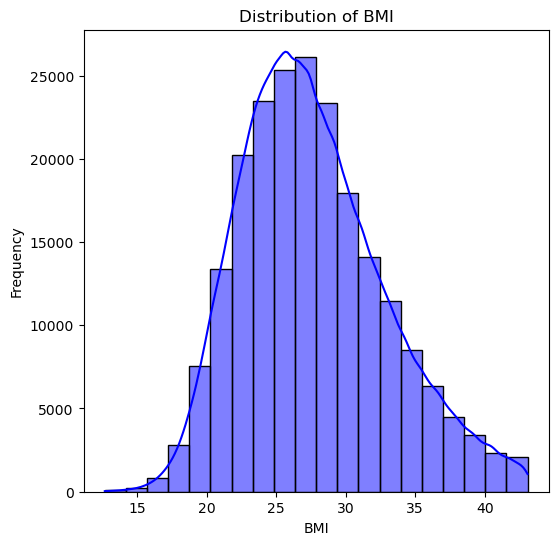

In [47]:
plt.figure(figsize=(6, 6))
sns.histplot(df['BMI'], kde=True, bins=20, color='blue')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

In [48]:
x_train.shape

(149769, 16)

In [49]:
y_train.shape

(149769,)

## Logistic Regression

In [51]:
LR = LogisticRegression(max_iter=1000)
LR.fit(x_train,y_train)
y_pred=LR.predict(x_test)
print(f"Accuracy Score:",accuracy_score(y_pred,y_test)*100)
print(f"Training Score:",LR.score(x_train,y_train)*100)
print(f"Confusion Matirx:\n",confusion_matrix(y_test,y_pred))
print(f"Precision Score:",precision_score(y_test,y_pred)*100)
print(f"Recall Score:",recall_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))
print(cross_val_score(LR,x,y,cv=5))

Accuracy Score: 92.64025425709256
Training Score: 92.59593106717678
Confusion Matirx:
 [[59261   178]
 [ 4546   202]]
Precision Score: 53.1578947368421
Recall Score: 4.254422914911542
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     59439
           1       0.53      0.04      0.08      4748

    accuracy                           0.93     64187
   macro avg       0.73      0.52      0.52     64187
weighted avg       0.90      0.93      0.90     64187

[0.92610768 0.9264565  0.92563857 0.92566194 0.92631628]


## Naive Bayes

In [53]:
NB=GaussianNB()
NB.fit(x_train,y_train)
y_pred=NB.predict(x_test)
print(f"Accuracy Score:",accuracy_score(y_pred,y_test)*100)
print(f"Training Score:",NB.score(x_train,y_train)*100)
print(f"Confusion Matirx:\n",confusion_matrix(y_test,y_pred))
print(f"Precision Score:",precision_score(y_test,y_pred)*100)
print(f"Recall Score:",recall_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))
print(cross_val_score(NB,x,y,cv=5))

Accuracy Score: 86.34302896225093
Training Score: 86.20341993336405
Confusion Matirx:
 [[53638  5801]
 [ 2965  1783]]
Precision Score: 23.510021097046412
Recall Score: 37.55265374894692
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     59439
           1       0.24      0.38      0.29      4748

    accuracy                           0.86     64187
   macro avg       0.59      0.64      0.61     64187
weighted avg       0.89      0.86      0.88     64187

[0.86392316 0.8640602  0.86319553 0.86025099 0.8606249 ]


### Decision Tree

In [55]:
DT=DecisionTreeClassifier()
DT.fit(x_train,y_train)
y_pred=DT.predict(x_test)
print(f"Accuracy Score:",accuracy_score(y_pred,y_test)*100)
print(f"Training Score:",DT.score(x_train,y_train)*100)
print(f"Confusion Matirx:",confusion_matrix(y_test,y_pred))
print(f"Precision Score:",precision_score(y_test,y_pred)*100)
print(f"Recall Score:",recall_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))
print(cross_val_score(DT,x,y,cv=5))

Accuracy Score: 87.55667035380996
Training Score: 99.52994277854562
Confusion Matirx: [[55258  4181]
 [ 3806   942]]
Precision Score: 18.387663478430607
Recall Score: 19.839932603201348
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     59439
           1       0.18      0.20      0.19      4748

    accuracy                           0.88     64187
   macro avg       0.56      0.56      0.56     64187
weighted avg       0.88      0.88      0.88     64187

[0.87126098 0.87443621 0.87266014 0.87464654 0.87445958]


## Random Forest 

In [57]:
RF=RandomForestClassifier(n_estimators=100)
RF.fit(x_train,y_train)
y_pred=RF.predict(x_test)
print(f"Accuracy Score:",accuracy_score(y_pred,y_test)*100)
print(f"Training Score:",RF.score(x_train,y_train)*100)
print(f"Confusion Matirx:",confusion_matrix(y_test,y_pred))
print(f"Precision Score:",precision_score(y_test,y_pred)*100)
print(f"Recall Score:",recall_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))
print(cross_val_score(RF,x,y,cv=5))

Accuracy Score: 91.1010017604811
Training Score: 99.52526891412775
Confusion Matirx: [[58105  1334]
 [ 4378   370]]
Precision Score: 21.71361502347418
Recall Score: 7.792754844144903
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     59439
           1       0.22      0.08      0.11      4748

    accuracy                           0.91     64187
   macro avg       0.57      0.53      0.53     64187
weighted avg       0.88      0.91      0.89     64187

[0.90827725 0.90839195 0.91028487 0.91037835 0.91107943]


# By Scratch Code

### Naive Bayes

In [60]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Initialize parameters
def initialize_naive_bayes():
    return {"priors": {}, "means": {}, "vars": {}, "classes": None}

# Fit the model
def fit_naive_bayes(X, y, model):
    model["classes"] = np.unique(y)
    for c in model["classes"]:
        X_c = X[y == c]
        model["priors"][c] = len(X_c) / len(X)
        model["means"][c] = X_c.mean(axis=0)
        model["vars"][c] = X_c.var(axis=0)

# Gaussian density function
def gaussian_density(mean, var, x):
    numerator = np.exp(-((x - mean) ** 2) / (2 * var + 1e-9))
    denominator = np.sqrt(2 * np.pi * var + 1e-9)
    return numerator / denominator

# Predict using the model
def predict_naive_bayes(X, model):
    predictions = []
    for x in X:
        class_probs = []
        for c in model["classes"]:
            prior = np.log(model["priors"][c] + 1e-9)
            conditional = np.sum(
                np.log(gaussian_density(model["means"][c], model["vars"][c], x) + 1e-9)
            )
            class_probs.append(prior + conditional)
        predictions.append(model["classes"][np.argmax(class_probs)])
    return np.array(predictions)

# Create and train the Naive Bayes model
naive_bayes_model = initialize_naive_bayes()
fit_naive_bayes(x_train, y_train, naive_bayes_model)

# Predict on train and test data
y_train_pred_nb = predict_naive_bayes(x_train, naive_bayes_model)
y_test_pred_nb = predict_naive_bayes(x_test, naive_bayes_model)

# Metrics for Naive Bayes
print(f"Naive Bayes Training Accuracy: {accuracy_score(y_train, y_train_pred_nb) * 100:.2f}%")
print(f"Naive Bayes Test Accuracy: {accuracy_score(y_test, y_test_pred_nb) * 100:.2f}%")
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_test_pred_nb))


Naive Bayes Training Accuracy: 86.23%
Naive Bayes Test Accuracy: 86.38%
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     59439
           1       0.24      0.38      0.29      4748

    accuracy                           0.86     64187
   macro avg       0.59      0.64      0.61     64187
weighted avg       0.89      0.86      0.88     64187



### Logistic Regression

In [62]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(x_train, y_train, learning_rate=0.01, epochs=1000):
    m, n = x_train.shape
    weights = np.zeros(n)
    bias = 0
    for epoch in range(epochs):
        z = np.dot(x_train, weights) + bias
        predictions = sigmoid(z)
        dw = (1/m) * np.dot(x_train.T, (predictions - y_train))
        db = (1/m) * np.sum(predictions - y_train)
        weights -= learning_rate * dw
        bias -= learning_rate * db
    return weights, bias

def predict(x_test, weights, bias):
    z = np.dot(x_test, weights) + bias
    predictions = sigmoid(z)
    return (predictions >= 0.5).astype(int)

def accuracy(y_test, y_pred):
    return np.mean(y_test == y_pred)

weights, bias = train(x_train, y_train, learning_rate=0.01, epochs=1000)

# Make predictions
y_train_pred = predict(x_train, weights, bias)
y_test_pred = predict(x_test, weights, bias)

# Calculate metrics
train_acc = accuracy(y_train, y_train_pred)
test_acc = accuracy(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 92.62%
Test Accuracy: 92.61%
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     59439
           1       0.51      0.01      0.03      4748

    accuracy                           0.93     64187
   macro avg       0.72      0.51      0.50     64187
weighted avg       0.90      0.93      0.89     64187



#### Result : Logistic Regression Performed the best with Accuracy Score: 92.6 and Training Score: 92.6